In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import math
from scipy.optimize import minimize
# import matplotlib.pyplot as plt
import warnings

## Epsilon Greedy Algorithm

In [ ]:
class EpsilonGreedy():
    def __init__(self, epsilon, counts, values):
        self.epsilon = epsilon
        self.counts = counts #Number of pulls for each arm.
        self.values = values #Average reward obtained by each arm.
        return

    #Initialize the number of arms and the reward values of each arm.
    def initialize(self, n_arms):
        self.counts = [0 for col in range(n_arms)]
        # self.values = [0.0 for col in range(n_arms)]
        self.values = [random.uniform(0, 0.01) for col in range(n_arms)]  # Small random values
        return

    def select_arm(self):
        #Exploitation
        if random.random() > self.epsilon:
            return np.argmax(self.values)
        #Exploration
        else:
            return random.randrange(len(self.values))


    def update(self, chosen_arm, reward):
        # Update the number of times each arm is chosen
        self.counts[chosen_arm] = self.counts[chosen_arm] + 1
        n = self.counts[chosen_arm]

        # Update average/mean value/reward for chosen arm
        value = self.values[chosen_arm]
        new_value = ((n-1)/float(n)) * value + (1 / float(n)) * reward
        self.values[chosen_arm] = new_value
        return

In [ ]:
# To implement a stochastic bandit based whose reward function is based on Bernoulli Distribution.
class BernoulliArm():
    def __init__(self, p):
        self.p = p

    # Reward system based on Bernoulli
    def draw(self):
        if random.random() > self.p:
            return 0.0
        else:
            return 1.0

In [ ]:
def test_algorithm(algo, arms, num_sims, horizon):

    # Initialise variables for duration of accumulated simulation (num_sims * horizon_per_simulation)
    chosen_arms = [0.0 for i in range(num_sims * horizon)]
    rewards = [0.0 for i in range(num_sims * horizon)]
    cumulative_rewards = [0 for i in range(num_sims * horizon)]
    sim_nums = [0.0 for i in range(num_sims *horizon)]
    times = [0.0 for i in range (num_sims*horizon)]

    for sim in range(num_sims):
        # print(sim)
        sim = sim + 1
        algo.initialize(len(arms))

        for t in range(horizon):
            # print(t)
            t = t + 1
            index = (sim -1) * horizon + t -1
            sim_nums[index] = sim
            times[index] = t

            # Selection of best arm and engaging it
            chosen_arm = algo.select_arm()
            chosen_arms[index] = chosen_arm

            # Engage chosen Bernoulli Arm and obtain reward info
            reward = arms[chosen_arm].draw()
            rewards[index] = reward

            if t ==1:
                cumulative_rewards[index] = reward
            else:
                cumulative_rewards[index] = cumulative_rewards[index-1] + reward

            algo.update(chosen_arm, reward)
    return [sim_nums, times, chosen_arms, rewards, cumulative_rewards]

In [ ]:
import random

# Intitailize Arms only once, use it for all the three algorithms
random.seed(1)
# out of 5 arms, 1 arm is clearly the best

# Here we take different types of means.
means = [0.1, 0.1, 0.1, 0.1, 0.8]
# means = [0.01, 0.03, 0.05, 0.03, 0.03] # Taking mean values very close to zero
# means = [0.91, 0.91, 0.86, 0.86, 0.95]
# means = [0.3, 0.6]  # Taking two arms
# means = np.random.uniform(0,1,200)  #Taking 200 arms
n_arms = len(means)
# Shuffling arms
random.shuffle(means)

# Create list of Bernoulli Arms with Reward Information
arms = list(map(lambda mu: BernoulliArm(mu), means)) # These are the objects of the Bernouli class we created above.
print("Best arm is " + str(np.argmax(means)))

f = open("standard_results_epsg.tsv", "w+")

# Create simulations for each exploration epsilon value
for epsilon in [0, 0.01, 0.1, 0.6, 1]:
    algo = EpsilonGreedy(epsilon, [], [])
    algo.initialize(n_arms)
    results = test_algorithm(algo, arms, 2000, 1000)

    # Store data
    for i in range(len(results[0])):
        f.write(str(epsilon) + "\t")
        f.write("\t".join([str(results[j][i]) for j in range(len(results))]) + "\n")
f.close()

Best arm is 2


In [ ]:
df = pd.read_csv("standard_results_epsg.tsv", sep = "\t", header = None, names = ["epsilon", "simulation_num", "step", "chosen_arm", "reward", "cum_reward"])
# df.head()

In [ ]:
best_arm = np.argmax(means)
df['best_arm_chosen'] = (df['chosen_arm'] == best_arm)

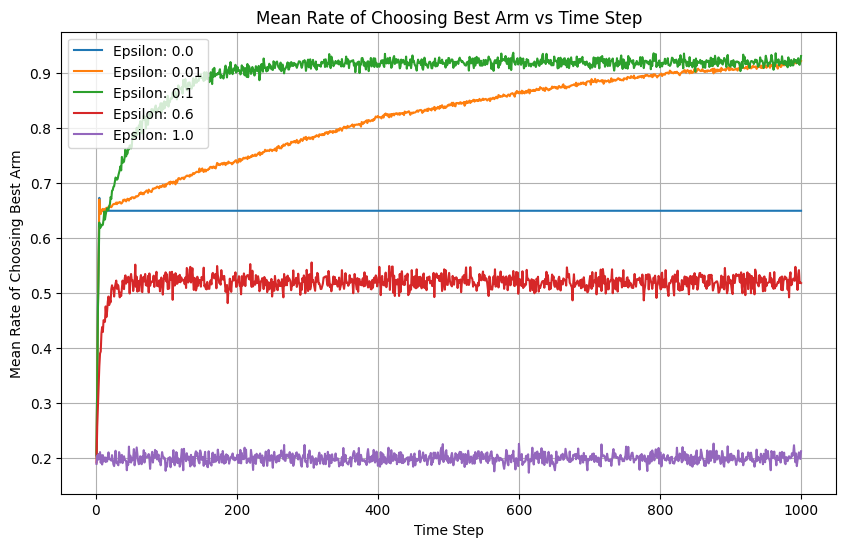

In [ ]:
grouped1 = df.groupby(["epsilon", "step"])["best_arm_chosen"].mean().reset_index()

# Step 3: Plot the mean rate of choosing the best arm vs time step for each epsilon
plt.figure(figsize=(10, 6))
for epsilon in grouped1["epsilon"].unique():
    subset = grouped1[grouped1["epsilon"] == epsilon]
    plt.plot(subset["step"], subset["best_arm_chosen"], label=f"Epsilon: {epsilon}")

plt.xlabel("Time Step")
plt.ylabel("Mean Rate of Choosing Best Arm")
plt.title("Mean Rate of Choosing Best Arm vs Time Step")
plt.legend()
plt.grid(True)
plt.show()

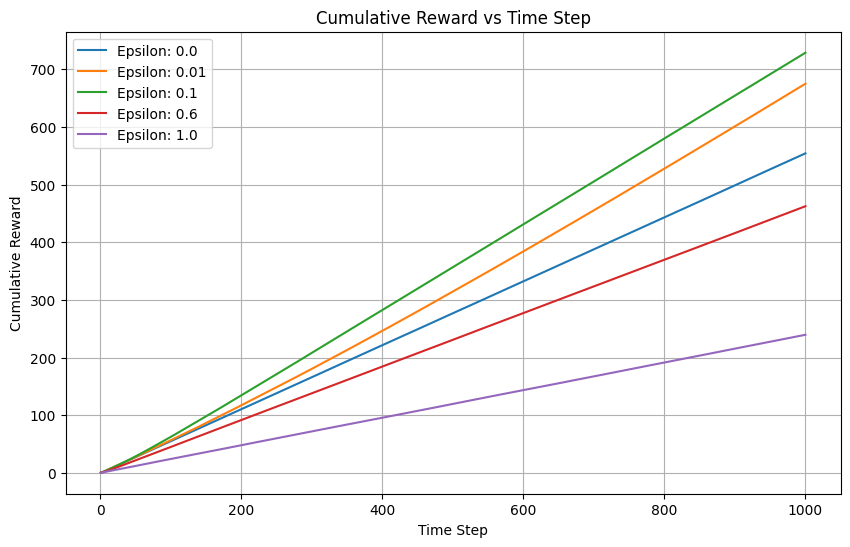

In [ ]:
grouped2 = df.groupby(["epsilon", "step"])["cum_reward"].mean().reset_index()

# Step 3: Plot the mean rate of choosing the best arm vs time step for each epsilon
plt.figure(figsize=(10, 6))
for epsilon in grouped2["epsilon"].unique():
    subset = grouped2[grouped2["epsilon"] == epsilon]
    plt.plot(subset["step"], subset["cum_reward"], label=f"Epsilon: {epsilon}")

plt.xlabel("Time Step")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward vs Time Step")
plt.legend()
plt.grid(True)
plt.show()

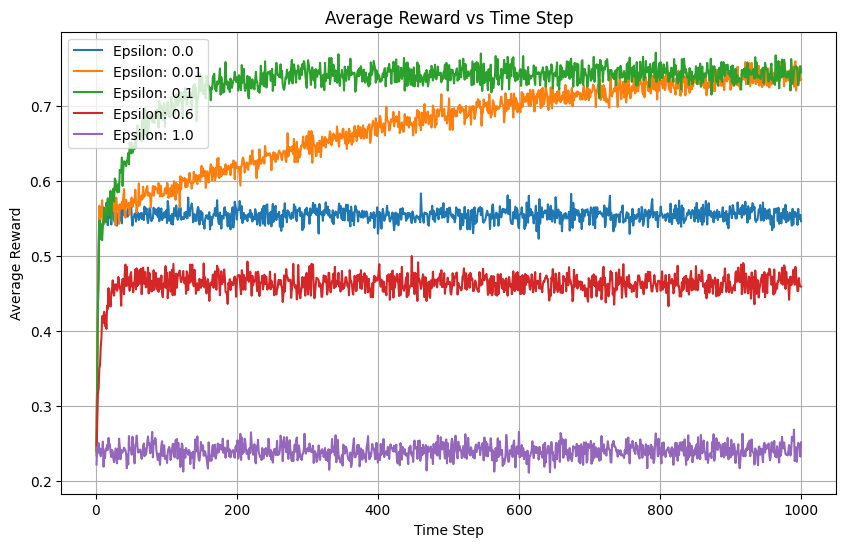

In [ ]:
grouped3 = df.groupby(["epsilon", "step"])["reward"].mean().reset_index()

# Step 3: Plot the mean rate of choosing the best arm vs time step for each epsilon
plt.figure(figsize=(10, 6))
for epsilon in grouped3["epsilon"].unique():
    subset = grouped3[grouped3["epsilon"] == epsilon]
    plt.plot(subset["step"], subset["reward"], label=f"Epsilon: {epsilon}")

plt.xlabel("Time Step")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Time Step")
plt.legend()
plt.grid(True)
plt.show()

#### Simulating Epsilon Greedy with 20 arms

In [ ]:
random.seed(1)
means_new = np.random.uniform(0,1,20)  #Taking 20 arms
n_arms = len(means_new)
# Shuffling arms
random.shuffle(means_new)

# Create list of Bernoulli Arms with Reward Information
arms_new = list(map(lambda mu: BernoulliArm(mu), means_new)) # These are the objects of the Bernouli class we created above.
print("Best arm is " + str(np.argmax(means_new)))

f = open("results_epsg_new.tsv", "w+")

# Create simulations for each exploration epsilon value
for epsilon in [0, 0.01, 0.1, 0.6, 1]:
    algo = EpsilonGreedy(epsilon, [], [])
    algo.initialize(n_arms)
    results = test_algorithm(algo, arms_new, 2500, 1000)

    # Store data
    for i in range(len(results[0])):
        f.write(str(epsilon) + "\t")
        f.write("\t".join([str(results[j][i]) for j in range(len(results))]) + "\n")
f.close()

Best arm is 2


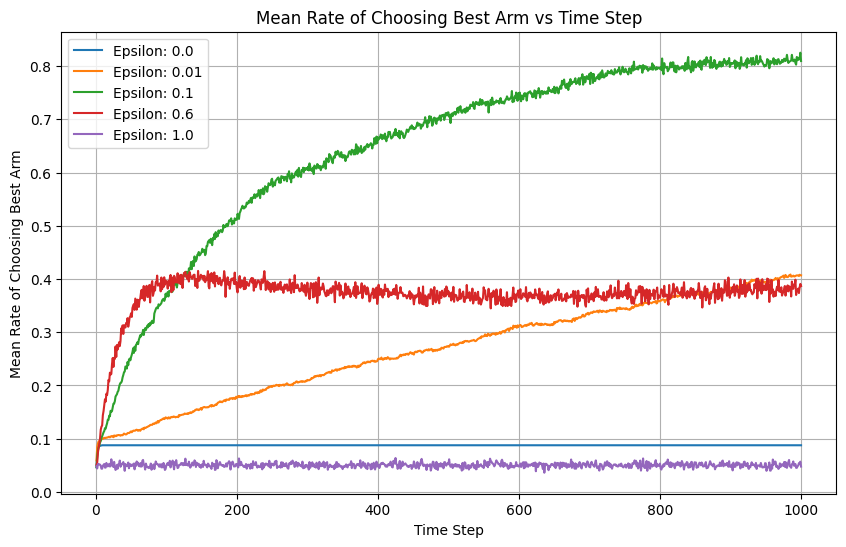

In [ ]:
df_new = pd.read_csv("results_epsg_new.tsv", sep = "\t", header = None, names = ["epsilon", "simulation_num", "step", "chosen_arm", "reward", "cum_reward"])
best_arm = np.argmax(means_new)
df_new['best_arm_chosen'] = (df_new['chosen_arm'] == best_arm)

grouped3 = df_new.groupby(["epsilon", "step"])["best_arm_chosen"].mean().reset_index()

# Step 3: Plot the mean rate of choosing the best arm vs time step for each epsilon
plt.figure(figsize=(10, 6))
for epsilon in grouped3["epsilon"].unique():
    subset = grouped3[grouped3["epsilon"] == epsilon]
    plt.plot(subset["step"], subset["best_arm_chosen"], label=f"Epsilon: {epsilon}")

plt.xlabel("Time Step")
plt.ylabel("Mean Rate of Choosing Best Arm")
plt.title("Mean Rate of Choosing Best Arm vs Time Step")
plt.legend()
plt.grid(True)
plt.show()

## Upper Confidence Bound Algorithm

In [ ]:
class UCB1():
    def __init__(self, counts, values):
        self.counts = counts #Number of pulls for each arm.
        self.values = values #Average reward obtained by each arm.
        return

    #Initialize the number of arms and the reward values of each arm.
    def initialize(self, n_arms):
        self.counts = [0 for col in range(n_arms)]
        self.values = [0.0 for col in range(n_arms)]
        return

    def select_arm(self):
        n_arms = len(self.counts)
        for arm in range(n_arms):
            if self.counts[arm] == 0: #To ensure that every single arm is played once.
                return arm

        ucb_values = [0.0 for arm in range(n_arms)]
        total_counts = sum(self.counts)

        for arm in range(n_arms):
            bonus = math.sqrt((1 * math.log(total_counts)) / float(self.counts[arm]))
            ucb_values[arm] = self.values[arm] + bonus
        return ucb_values.index(max(ucb_values))

    def update(self, chosen_arm, reward):
        # Update the number of times each arm is chosen
        self.counts[chosen_arm] = self.counts[chosen_arm] + 1
        n = self.counts[chosen_arm]

        # Update average/mean value/reward for chosen arm
        value = self.values[chosen_arm]
        new_value = ((n-1)/float(n)) * value + (1 / float(n)) * reward
        self.values[chosen_arm] = new_value
        return

In [ ]:
# Create list of Bernoulli Arms with Reward Information
arms = list(map(lambda mu: BernoulliArm(mu), means)) # These are the objects of the Bernouli class we created above.
print("Best arm is " + str(np.argmax(means)))

f = open("standard_ucb_results.tsv", "w+")
# Create 1 round of 5000 simulations
algo = UCB1([], [])
algo.initialize(n_arms)
results = test_algorithm(algo, arms, 2000, 1000)

# Store data
for i in range(len(results[0])):
    f.write("\t".join([str(results[j][i]) for j in range(len(results))]) + "\n")
f.close()
print("done")

Best arm is 2
done


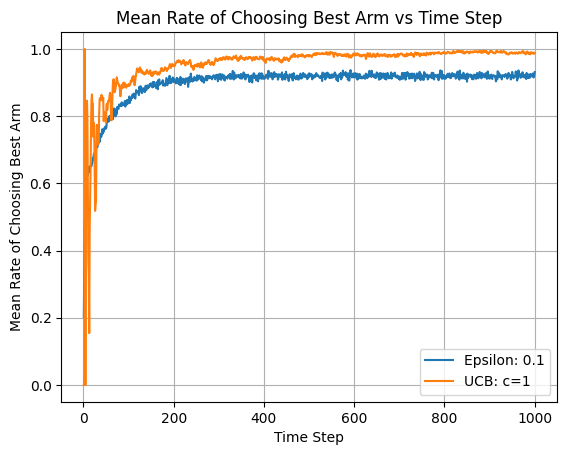

In [ ]:
df_ucb = pd.read_csv("standard_ucb_results.tsv", sep = "\t", header = None, names = ["simulation_num", "step", "chosen_arm", "reward", "cum_reward"])
df_ucb['best_arm_chosen'] = (df_ucb['chosen_arm'] == best_arm)
df_ucb_correct = df_ucb.groupby(["step"])["best_arm_chosen"].mean().reset_index()


subset = grouped1[grouped1["epsilon"] == 0.1]
plt.plot(subset["step"], subset["best_arm_chosen"], label=f"Epsilon: {0.1}")
plt.plot(df_ucb_correct['step'], df_ucb_correct['best_arm_chosen'], label="UCB: c=1")

plt.xlabel("Time Step")
plt.ylabel("Mean Rate of Choosing Best Arm")
plt.title("Mean Rate of Choosing Best Arm vs Time Step")
plt.legend()
plt.grid(True)
plt.show()

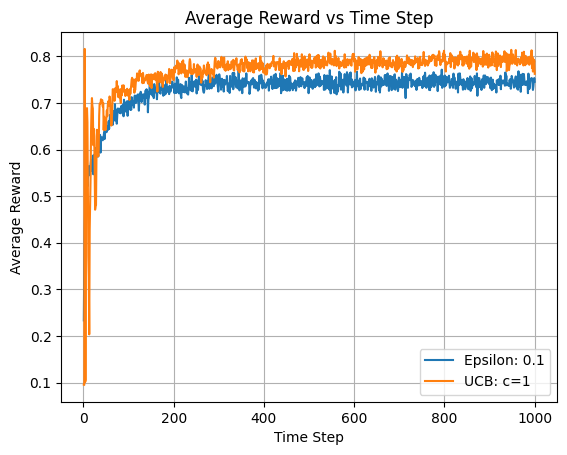

In [ ]:
df_ucb_rew = df_ucb.groupby(["step"])["reward"].mean().reset_index()

subset = grouped3[grouped3["epsilon"] == 0.1]
plt.plot(subset["step"], subset["reward"], label=f"Epsilon: {0.1}")

plt.plot(df_ucb_rew['step'], df_ucb_rew['reward'], label=f"UCB: c={1}")
plt.xlabel("Time Step")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Time Step")
plt.legend()
plt.grid(True)
plt.show()

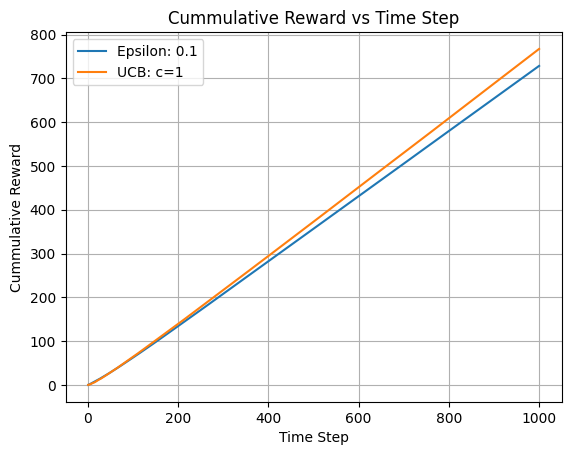

In [ ]:
df_ucb_cum = df_ucb.groupby(["step"])["cum_reward"].mean().reset_index()
subset = grouped2[grouped2["epsilon"] == 0.1]
plt.plot(subset["step"], subset["cum_reward"], label=f"Epsilon: {0.1}")


plt.plot(df_ucb_cum['step'], df_ucb_cum['cum_reward'], label="UCB: c=1")
plt.xlabel("Time Step")
plt.ylabel("Cummulative Reward")
plt.title("Cummulative Reward vs Time Step")
plt.legend()
plt.grid(True)
plt.show()

#### Simulating UCB with 20 arms.

In [ ]:
# random.seed(1)
# means_new = np.random.uniform(0,1,20)
n_arms = len(means_new)
# Shuffling arms
# random.shuffle(means_new)

# Create list of Bernoulli Arms with Reward Information
arms_new = list(map(lambda mu: BernoulliArm(mu), means_new)) # These are the objects of the Bernouli class we created above.
print("Best arm is " + str(np.argmax(means_new)))

f = open("ucb_results_new.tsv", "w+")
# Create 1 round of 5000 simulations
algo_new = UCB1([], [])
algo_new.initialize(n_arms)
results = test_algorithm(algo_new, arms_new, 2500, 500)

# Store data
for i in range(len(results[0])):
    f.write("\t".join([str(results[j][i]) for j in range(len(results))]) + "\n")
f.close()
print("done")

Best arm is 18
done


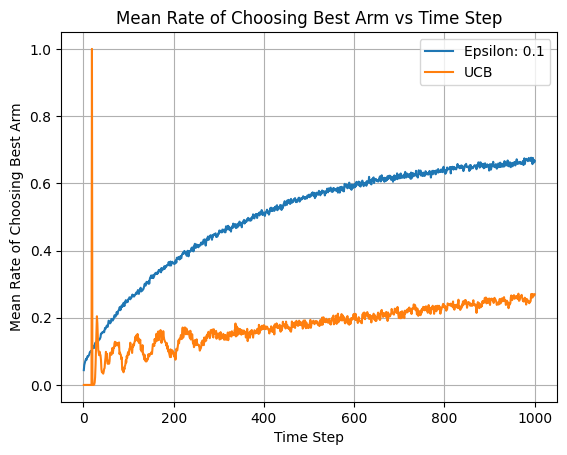

In [ ]:
df_ucb_new = pd.read_csv("ucb_results_new.tsv", sep = "\t", header = None, names = ["simulation_num", "step", "chosen_arm", "reward", "cum_reward"])
df_ucb_new['best_arm_chosen'] = (df_ucb_new['chosen_arm'] == best_arm)
df_ucb_correct_new = df_ucb_new.groupby(["step"])["best_arm_chosen"].mean().reset_index()


subset = grouped3[grouped3["epsilon"] == 0.1]
plt.plot(subset["step"], subset["best_arm_chosen"], label=f"Epsilon: {0.1}")
plt.plot(df_ucb_correct_new['step'], df_ucb_correct_new['best_arm_chosen'], label="UCB")

plt.xlabel("Time Step")
plt.ylabel("Mean Rate of Choosing Best Arm")
plt.title("Mean Rate of Choosing Best Arm vs Time Step")
plt.legend()
plt.grid(True)
plt.show()

## Thompson Sampling

In [ ]:
from scipy.stats import beta

In [ ]:
class ThompsonSampling():

     def __init__(self, counts, values, a, b):
        self.counts = counts #Number of pulls for each arm.
        self.values = values #Average reward obtained by each arm.

        # Beta parameters
        self.a = a
        self.b = b
        return

       # Initialise k number of arms
     def initialize(self, n_arms):
        self.counts = [0 for col in range(n_arms)]
        self.values = [0.0 for col in range(n_arms)]

        # Uniform distribution of prior beta (A,B)
        self.a = [1 for arm in range(n_arms)]
        self.b = [1 for arm in range(n_arms)]
        return

        # Thompson Sampling selection of arm for each round
     def select_arm(self):
        n_arms = len(self.counts)

        # Pair up all beta params of a and b for each arm
        beta_params = zip(self.a, self.b)

        # Perform random draw for all arms based on their params (a,b)
        all_draws = [beta.rvs(i[0], i[1], size = 1) for i in beta_params]

        # return index of arm with the highest draw
        return all_draws.index(max(all_draws))


     # Choose to update chosen arm and reward
     def update(self, chosen_arm, reward):
        # update counts pulled for chosen arm
        self.counts[chosen_arm] = self.counts[chosen_arm] + 1
        n = self.counts[chosen_arm]

        # Update average/mean value/reward for chosen arm
        value = self.values[chosen_arm]
        new_value = ((n - 1) / float(n)) * value + (1 / float(n)) * reward
        self.values[chosen_arm] = new_value

        # Update a and b

        # a is based on total counts of rewards of arm
        self.a[chosen_arm] = self.a[chosen_arm] + reward

        # b is based on total counts of failed rewards on arm
        self.b[chosen_arm] = self.b[chosen_arm] + (1-reward)

        return

In [ ]:
# Create list of Bernoulli Arms with Reward Information
arms = list(map(lambda mu: BernoulliArm(mu), means)) # These are the objects of the Bernouli class we created above.
print("Best arm is " + str(np.argmax(means)))

f = open("standard_ts_results.tsv", "w+")

# Create simulations for ThompsonSampling
algo = ThompsonSampling([], [], [], [])
algo.initialize(n_arms)
results = test_algorithm(algo, arms, 2000, 1000)

# Store data
for i in range(len(results[0])):
    f.write("\t".join([str(results[j][i]) for j in range(len(results))]) + "\n")
f.close()

Best arm is 2


In [ ]:
df_ts = pd.read_csv("standard_ts_results.tsv", sep = "\t", header = None, names = ["simulation_num", "step", "chosen_arm", "reward", "cum_reward"])
best_arm = np.argmax(means)
df_ts['best_arm_chosen'] = (df_ts['chosen_arm'] == best_arm)

In [ ]:
print(df_ts.head())

   simulation_num  step  chosen_arm  reward  cum_reward  best_arm_chosen
0               1     1           0     0.0         0.0            False
1               1     2           4     0.0         0.0            False
2               1     3           3     0.0         0.0            False
3               1     4           1     0.0         0.0            False
4               1     5           0     0.0         0.0            False


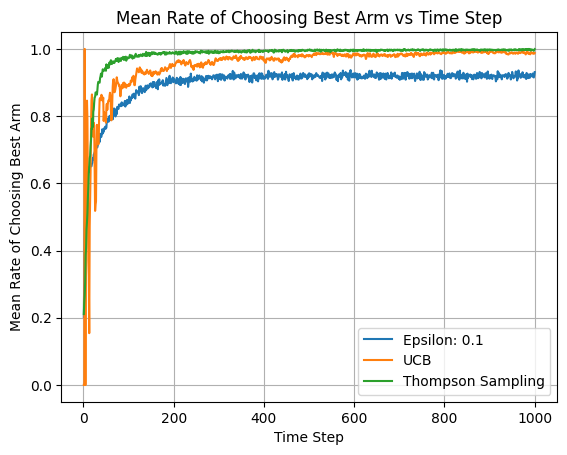

In [ ]:
df_ts_correct = df_ts.groupby(["step"])["best_arm_chosen"].mean().reset_index()

subset = grouped1[grouped1["epsilon"] == 0.1]
plt.plot(subset["step"], subset["best_arm_chosen"], label=f"Epsilon: {0.1}")

plt.plot(df_ucb_correct['step'], df_ucb_correct['best_arm_chosen'], label="UCB")
plt.plot(df_ts_correct['step'], df_ts_correct['best_arm_chosen'], label="Thompson Sampling")

plt.xlabel("Time Step")
plt.ylabel("Mean Rate of Choosing Best Arm")
plt.title("Mean Rate of Choosing Best Arm vs Time Step")
plt.legend()
plt.grid(True)
plt.show()

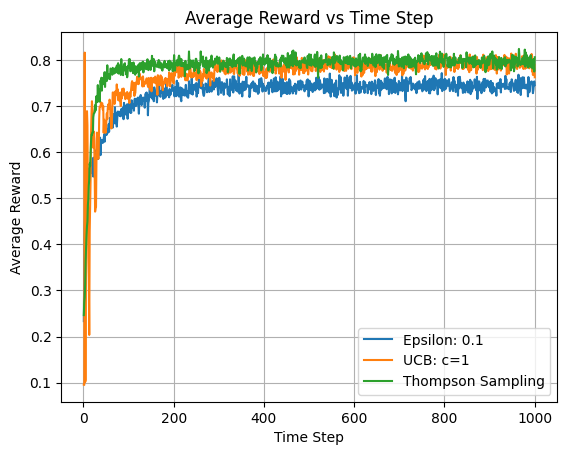

In [ ]:
df_ts_rew = df_ts.groupby(["step"])["reward"].mean().reset_index()

subset = grouped3[grouped3["epsilon"] == 0.1]
plt.plot(subset["step"], subset["reward"], label=f"Epsilon: {0.1}")

plt.plot(df_ucb_rew['step'], df_ucb_rew['reward'], label=f"UCB: c={1}")
plt.plot(df_ts_rew['step'], df_ts_rew['reward'], label="Thompson Sampling")

plt.xlabel("Time Step")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Time Step")
plt.legend()
plt.grid(True)
plt.show()


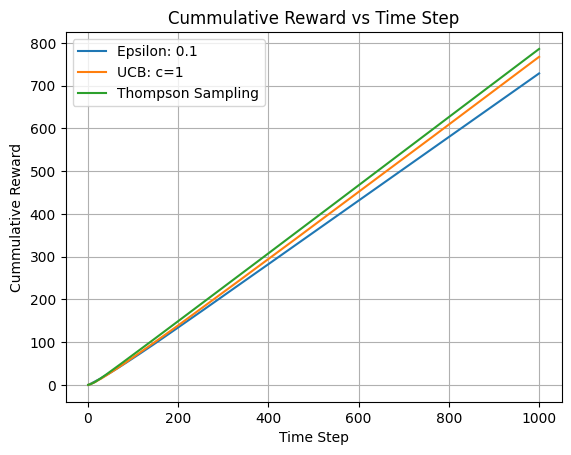

In [ ]:
df_ts_cumm = df_ts.groupby(["step"])["cum_reward"].mean().reset_index()
subset = grouped2[grouped2["epsilon"] == 0.1]


plt.plot(subset["step"], subset["cum_reward"], label=f"Epsilon: {0.1}")
plt.plot(df_ucb_cum['step'], df_ucb_cum['cum_reward'], label="UCB: c=1")
plt.plot(df_ts_cumm['step'], df_ts_cumm['cum_reward'], label="Thompson Sampling")

plt.xlabel("Time Step")
plt.ylabel("Cummulative Reward")
plt.title("Cummulative Reward vs Time Step")
plt.legend()
plt.grid(True)
plt.show()

## EXP3

In [ ]:
class EXP3():
    def __init__(self, num_arms, gamma, eta):
        self.num_arms = num_arms
        # self.rounds = rounds
        self.gamma = gamma
        self.eta = eta
        self.weights = self.init_weights(num_arms)

        return

    def init_weights(self, num_arms):
        return np.ones(num_arms)

    def calculate_probabilities(self):
        total_weight = np.sum(self.weights)
        probabilities = (1 - self.gamma) * (self.weights / total_weight) + (self.gamma / self.num_arms)
        return probabilities

    def select_arm(self):
        # Calculate the probabilities of each arm based on current weights
        probabilities = self.calculate_probabilities()

        # Select an arm based on the calculated probabilities
        chosen_arm = np.random.choice(self.num_arms, p=probabilities)

        return probabilities, chosen_arm

    def simulate_reward(self, chosen_arm):
        # Here we can define any reward structure, e.g., random rewards
        return np.random.binomial(1, 0.5)  # reward of 1 with probability 0.5

    def update_weights(self, chosen_arm, reward, probabilities):
        # Calculate the estimated (importance-weighted) reward
        estimated_reward = reward / probabilities[chosen_arm]

        # Update the weight of the chosen arm
        self.weights[chosen_arm] *= np.exp(self.eta * estimated_reward)
        return

In [ ]:
def run(algo, rounds):
    # Lists to store results
    chosen_arms = []
    probabilities_history = []
    rewards = []


    # Run the EXP3 algorithm over the specified rounds
    for _ in range(rounds):

        # Select an arm based on the calculated probabilities
        probabilities, chosen_arm = algo.select_arm()

        # Simulate the reward for the chosen arm
        reward = algo.simulate_reward(chosen_arm)

        # Update the weights based on the observed reward
        algo.update_weights(chosen_arm, reward, probabilities)

        # Store results for analysis
        chosen_arms.append(chosen_arm)
        probabilities_history.append(probabilities)
        rewards.append(reward)

    return chosen_arms, probabilities_history, rewards

In [ ]:
num_arms = 3
rounds = 1000
gamma = 0.1
eta = 0.1

# Initialize the EXP3 instance
exp3 = EXP3(num_arms, gamma, eta)

chosen_arms, probabilities_history, rewards = run(exp3, rounds)

chosen_arms = np.array(chosen_arms)
rewards = np.array(rewards)
probabilities_history = np.array(probabilities_history)

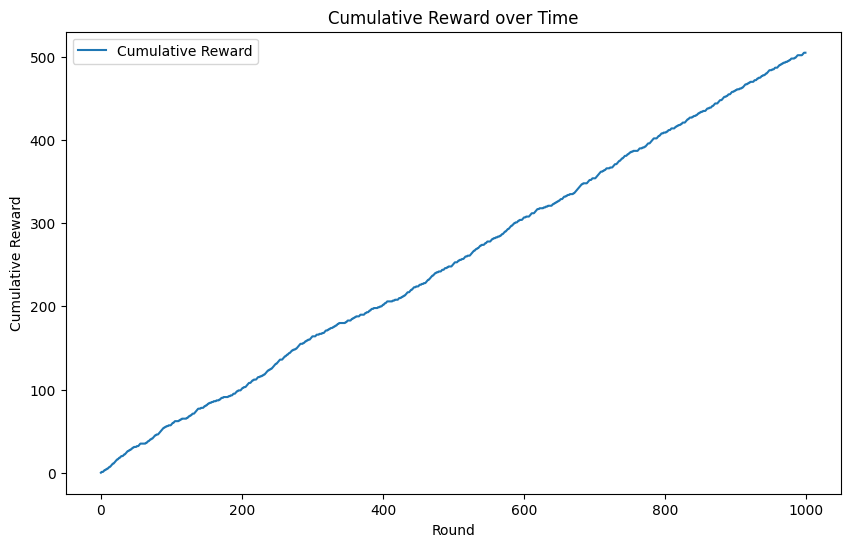

In [ ]:
# 1. Cumulative Reward Plot
cumulative_rewards = np.cumsum(rewards)
plt.figure(figsize=(10, 6))
plt.plot(cumulative_rewards, label="Cumulative Reward")
plt.xlabel("Round")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Reward over Time")
plt.legend()
plt.show()

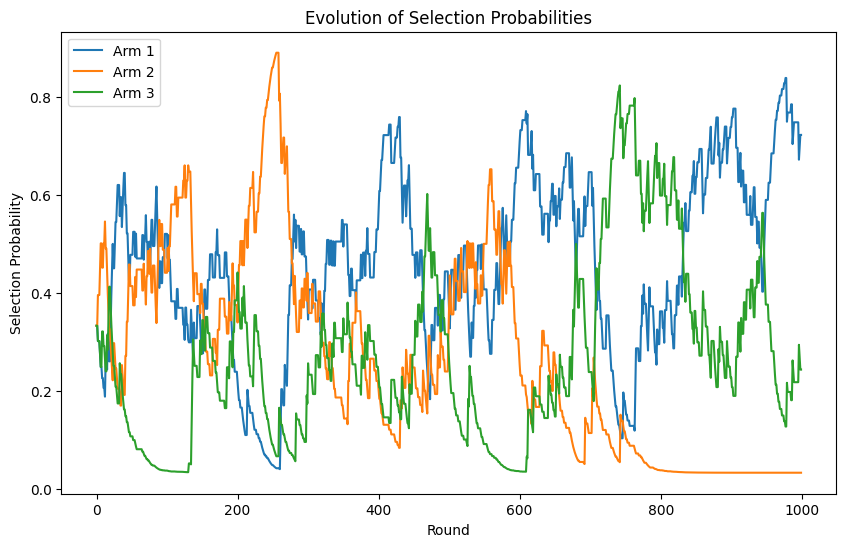

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(probabilities_history.shape[1]):
    plt.plot(probabilities_history[:, i], label=f"Arm {i+1}")
plt.xlabel("Round")
plt.ylabel("Selection Probability")
plt.title("Evolution of Selection Probabilities")
plt.legend()
plt.show()

## Contextual Bandits

In [ ]:
import plotly.offline
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import cufflinks as cf

In [ ]:
cf.go_offline()
cf.set_config_file(world_readable=True, theme='white')

In [ ]:
class UserGenerator(object):
    def __init__(self):
        self.beta = {}
        self.beta['C'] = np.array([-6, -0.1, 1, 0.1])
        self.beta['T'] = np.array([-3.5, -0.1, -3, 0.1])
        self.context = None

    def logistic(self, beta, context):
        f = np.dot(beta, context)
        p = 1 / (1 + np.exp(-f))
        return p

    def display_ad(self, ad):
        if ad in ['C', 'T']:
            p = self.logistic(self.beta[ad], self.context)
            reward = np.random.binomial(n=1, p=p)
            return reward
        else:
            raise Exception('Unknown ad!')

    def generate_user_with_context(self):
        # 0: International, 1: U.S.
        location = np.random.binomial(n=1, p=0.6)
        # 0: Desktop, 1: Mobile
        device = np.random.binomial(n=1, p=0.8)
        age = 10 + int(np.random.beta(2, 3) * 60)
        self.context = [1, device, location, age]
        return self.context

In [ ]:
def get_scatter(x, y, name, showlegend):

    dashmap = {'C': 'solid',
    'T': 'dot'}

    s = go.Scatter(x=x,
        y=y,
        legendgroup=name,
        showlegend=showlegend,
        name=name,
        line=dict(color='blue',dash=dashmap[name]))

    return s

In [ ]:
def visualize_bandits(ug):
    ad_list = 'CT'
    ages = np.linspace(10, 70)
    fig = make_subplots(rows=2, cols=2,
            subplot_titles=("Desktop, International",
                            "Desktop, U.S.",
                            "Mobile, International",
                            "Mobile, U.S."))
    for device in [0, 1]:
        for loc in [0, 1]:
            showlegend = (device == 0) & (loc == 0)
            for ad in ad_list:
                probs = [ug.logistic(ug.beta[ad],
                          [1, device, loc, age])
                                 for age in ages]
                fig.add_trace(get_scatter(ages,
                                          probs,
                                          ad,
                                          showlegend),
                           row=device+1,
                           col=loc+1)
    fig.update_layout(template="presentation")
    fig.show()

References:
1. Bandit Algorithms For Website Optimization - John Myles White
2. Bandit Simulations (https://github.com/kfoofw/bandit_simulations)